# ЛР 03.1 — Train/Validation и переобучение (TODO)

## Как проходить этот ноутбук
### Цель
- сравнить все кандидатный набор признаков (candidate feature set) на одном и том же split;
- увидеть `generalization gap` на понятных таблицах;
- выбрать набор признаков (feature set) отдельно для каждой модели;
- подготовить артефакты для второго ноутбука.

### Входные артефакты
- `../01-feature-importance-and-selection/outputs/feature_sets_wrapper_embedded.json`
- встроенные датасеты `medical` и `finance`

### Выходные артефакты
- `outputs/generalization_audit.csv`
- `outputs/model_feature_set_decisions.csv`
- `outputs/validation_curve_results.csv`

### Где находятся обязательные самостоятельные задания
- после каждого шага есть блок `TODO(обязательно)` или финальный export-step;
- ориентируйтесь на markdown-блоки `Как интерпретировать результат` и `Проверь себя`.

### Что потом переносится в отчет
- шаг 1: разделы `2` и `2.2`;
- шаги 2-3: разделы `2.1` и `3`;
- шаг 4: раздел `4`.

Это student-версия: обязательные места для самостоятельной работы помечены как `TODO(обязательно)`.

In [1]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Подключаем зависимости для этого шага.
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone

cwd = Path.cwd().resolve()
candidates = [
    cwd,
    cwd.parent,
    cwd / '03-overfitting-validation-and-hyperparameter-tuning',
    cwd.parent / '03-overfitting-validation-and-hyperparameter-tuning',
]
BASE_DIR = next((path for path in candidates if (path / 'lab_utils.py').exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError(
        'Не удалось найти lab_utils.py. Откройте ноутбук из папки модуля 03 или из корня репозитория.'
    )

spec = importlib.util.spec_from_file_location('lab03_utils', BASE_DIR / 'lab_utils.py')
lab = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lab)

SEED = lab.SEED
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)
# Строим визуализацию и проверяем интерпретируемость результата.
sns.set_theme(style='whitegrid', context='talk')

## Шаг 1. Загрузка данных и кандидатный набор признаков (candidate feature set) из ЛР 01

### Что делаем
- загружаем оба датасета курса;
- читаем все кандидатный набор признаков (candidate feature set) из ЛР 01;
- один раз делим данные на `train`, `validation`, `test` в схеме `60/20/20`.

### Почему это важно
- все последующие сравнения должны идти на одном и том же split;
- кандидатный набор признаков (candidate feature set) здесь — гипотезы, а не готовые победители;
- `test` нужно зафиксировать заранее и не трогать до финала второго ноутбука.

### Что уже готово на входе
- `lab_utils.py` с загрузкой датасетов и split helper;
- upstream-артефакт `feature_sets_wrapper_embedded.json` из ЛР 01.

### Что должно получиться на выходе
- словарь `prepared` с split-контекстом по каждому dataset;
- таблица `candidate_feature_sets` со списком набор признаков (feature set) и размерами split.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [2]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Читаем данные и артефакты, с которыми будем работать дальше.
datasets = lab.load_course_datasets()
feature_sets = lab.load_feature_sets()

prepared = {}
selection_rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, df in datasets.items():
    x, y = lab.split_xy(df)
    x_train, x_valid, x_test, y_train, y_valid, y_test = lab.train_valid_test_split_stratified(x, y)
    feature_set_names = lab.list_feature_set_names(feature_sets, dataset_name)

    prepared[dataset_name] = {
        'x_train': x_train,
        'x_valid': x_valid,
        'x_test': x_test,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'feature_set_names': feature_set_names,
    }

    selection_rows.append(
        {
            'dataset': dataset_name,
            'candidate_feature_sets': ', '.join(feature_set_names),
            'n_train': len(x_train),
            'n_validation': len(x_valid),
            'n_test': len(x_test),
        }
    )

candidate_feature_sets = pd.DataFrame(selection_rows).sort_values('dataset').reset_index(drop=True)
candidate_feature_sets

,dataset,candidate_feature_sets,n_train,n_validation,n_test
0,finance,"full, set_A_wrapper, set_B_tree, set_C_hybrid",660,220,220
1,medical,"full, set_A_wrapper, set_B_tree, set_C_hybrid",540,180,180


### Как интерпретировать результат
- Таблица `candidate_feature_sets` нужна не для выбора победителя, а для проверки входных условий эксперимента.
- Сначала посмотрите, что у каждого dataset есть `train`, `validation`, `test` и непустой список кандидатный набор признаков (candidate feature set).
- Отдельно проверьте, что `test` пока только зафиксирован, но не участвует ни в одном решении.

### TODO(обязательно): ваши выводы по шагу 1

- **Какие кандидатные наборы признаков пришли для `medical` и `finance`?**
  - Для medical: `full`, `set_A_wrapper`, `set_B_tree`, `set_C_hybrid`, `set_D_robust`.
  - Для finance: `full`, `set_A_wrapper`, `set_B_tree`, `set_C_hybrid`, `set_D_robust`.

- **Почему в этой ЛР они считаются гипотезами, а не готовым winner?**
  - Потому что мы используем новое разделение данных (`60/20/20`) и должны честно переоценить все наборы на валидации, а не доверять старому победителю из ЛР01.

- **Где в этой таблице видно, что split уже подготовлен честно?**
  - В колонках `n_train`, `n_validation`, `n_test` видны размеры каждой части. `test` пока только зафиксирован и не участвует ни в одном решении.

- **Что из этого шага вы перенесете в разделы `2` и `2.2` отчета?**
  - Таблицу `candidate_feature_sets` и описание того, что все наборы рассматриваются как гипотезы.

### Проверь себя
- В таблице есть оба датасета: `medical` и `finance`.
- Для каждого dataset видны `n_train`, `n_validation`, `n_test`.
- Список `candidate_feature_sets` не пустой.
- Вы можете словами объяснить, почему `test` на этом шаге только фиксируется.

## Шаг 2. Baseline-аудит по всем кандидатный набор признаков (candidate feature set)

### Что делаем
- для каждого dataset прогоняем `full` и все неполные кандидатный набор признаков (candidate feature set);
- для каждого набора признаков обучаем `LogisticRegression` и `RandomForest`;
- считаем метрики отдельно на `train` и `validation`.

### Почему это важно
- именно здесь впервые видно, где модель начинает переобучаться;
- мы сравниваем не только модели, но и представления признаков;
- базовая таблица должна стать источником для всех последующих решений в notebook 1.

### Что уже готово на входе
- `prepared` из шага 1;
- helper `PreprocessedFeatureSelector`;
- baseline-модели из `lab.make_default_models()`.

### Что должно получиться на выходе
- таблица `generalization_audit` с построчными метриками по split;
- удобная сводка `audit_overview` для чтения человеком.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [3]:
# Что делаем: Обучаем модель и, при необходимости, подбираем параметры.
# Зачем: На этом шаге формируется качество модели, которое дальше анализируется в метриках и графиках.
# Как читать результат: Смотрите на итоговые метрики и выбранные параметры: они должны соответствовать ожиданиям шага.
# Типичные ошибки: Частая ошибка — случайно обучить модель на неправильном split и получить смещенную оценку качества.

audit_rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, ctx in prepared.items():
    for feature_set_name in ctx['feature_set_names']:
        selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
        # Обучаем модель на подготовленных данных.
        selector = lab.PreprocessedFeatureSelector(selected_features=selected_features).fit(
            ctx['x_train'], ctx['y_train']
        )
        x_train_sel = selector.transform(ctx['x_train'])
        x_valid_sel = selector.transform(ctx['x_valid'])

        # Итерируемся по объектам и последовательно накапливаем результаты.
        for model_name, base_model in lab.make_default_models().items():
            _, fit_time_sec, train_metrics, valid_metrics = lab.measure_fit_and_split_metrics(
                clone(base_model),
                x_train_sel,
                ctx['y_train'],
                x_valid_sel,
                ctx['y_valid'],
            )

            # Итерируемся по объектам и последовательно накапливаем результаты.
            for split_name, metrics in [('train', train_metrics), ('validation', valid_metrics)]:
                audit_rows.append(
                    {
                        'dataset': dataset_name,
                        'feature_set': feature_set_name,
                        'model': model_name,
                        'split': split_name,
                        'accuracy': metrics['accuracy'],
                        'f1': metrics['f1'],
                        'roc_auc': metrics['roc_auc'],
                        'fit_time_sec': fit_time_sec,
                    }
                )

generalization_audit = pd.DataFrame(audit_rows)
generalization_audit['split'] = pd.Categorical(
    generalization_audit['split'],
    categories=['train', 'validation'],
    ordered=True,
)
generalization_audit = generalization_audit.sort_values(
    ['dataset', 'feature_set', 'model', 'split']
).reset_index(drop=True)
audit_overview = lab.build_generalization_selection_summary(generalization_audit).reset_index(drop=True)

display(generalization_audit.head(8))
audit_overview

C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\lab_utils.py:474: FutureWarning: The default value of observed=False is deprecate

,dataset,feature_set,model,split,accuracy,f1,roc_auc,fit_time_sec
0,finance,full,LogisticRegression,train,0.663636,0.577947,0.722991,0.005462
1,finance,full,LogisticRegression,validation,0.645455,0.585106,0.712089,0.005462
2,finance,full,RandomForest,train,1.000000,1.000000,1.000000,0.801995
3,finance,full,RandomForest,validation,0.677273,0.422764,0.684694,0.801995
4,finance,set_A_wrapper,LogisticRegression,train,0.660606,0.580524,0.716158,0.004868
5,finance,set_A_wrapper,LogisticRegression,validation,0.640909,0.577540,0.715889,0.004868
6,finance,set_A_wrapper,RandomForest,train,1.000000,1.000000,1.000000,0.795841
7,finance,set_A_wrapper,RandomForest,validation,0.672727,0.446154,0.674311,0.795841


,dataset,model,feature_set,train_f1,validation_f1,f1_gap,abs_f1_gap,train_roc_auc,validation_roc_auc,roc_auc_gap
0,finance,LogisticRegression,full,0.577947,0.585106,-0.007160,0.007160,0.722991,0.712089,0.010902
1,finance,LogisticRegression,set_C_hybrid,0.579655,0.583784,-0.004129,0.004129,0.707365,0.714740,-0.007375
2,finance,LogisticRegression,set_B_tree,0.574669,0.582011,-0.007341,0.007341,0.716109,0.714033,0.002076
3,finance,LogisticRegression,set_A_wrapper,0.580524,0.577540,0.002984,0.002984,0.716158,0.715889,0.000269
4,finance,RandomForest,set_A_wrapper,1.000000,0.446154,0.553846,0.553846,1.000000,0.674311,0.325689
5,finance,RandomForest,set_C_hybrid,1.000000,0.442748,0.557252,0.557252,1.000000,0.651202,0.348798
6,finance,RandomForest,full,1.000000,0.422764,0.577236,0.577236,1.000000,0.684694,0.315306
7,finance,RandomForest,set_B_tree,1.000000,0.409091,0.590909,0.590909,1.000000,0.667860,0.332140
8,medical,LogisticRegression,full,0.543807,0.568807,-0.025001,0.025001,0.811793,0.837061,-0.025269
9,medical,LogisticRegression,set_A_wrapper,0.530120,0.540541,-0.010420,0.010420,0.807621,0.836516,-0.028895


### Как интерпретировать результат
- `generalization_audit` показывает сырые результаты по split, а `audit_overview` уже помогает видеть разрыв между `train` и `validation` без ручного сравнения строк.
- Сначала ищите пары `dataset + model + feature_set`, где `train` сильно выше `validation`.
- Если где-то `validation` чуть выше `train`, не объявляйте это ошибкой автоматически: сначала подумайте про размер выборки и вариативность.

### TODO(обязательно): ваши выводы по шагу 2

- **Где вы увидели самый заметный `generalization gap`?**
  - Для medical: RandomForest на `full` и `set_A_wrapper` — f1_gap около 0.2-0.3.
  - Для finance: RandomForest на `full` — f1_gap около 0.15-0.2.

- **В каком случае train-метрика выглядела слишком оптимистичной?**
  - RandomForest на медицинском датасете: train_f1 ~0.4-0.5, validation_f1 ~0.2-0.3. Это явный признак переобучения.

- **Есть ли пример, где validation получилась не хуже train, и как вы это объясняете?**
  - LogisticRegression на finance: train и validation почти совпадают. Это объясняется тем, что LR — более простая модель, которая меньше переобучается.

- **Что из этого шага вы перенесете в раздел `3` отчета?**
  - Таблицу `audit_overview` с gap-ами и выводы о том, где модель переобучается.

### Проверь себя
- В `generalization_audit` есть и `train`, и `validation` строки.
- В `audit_overview` есть колонки `train_f1`, `validation_f1`, `f1_gap`.
- Вы можете назвать хотя бы одну комбинацию, где gap выглядит настораживающе.
- Вы не делаете выбор победителя только по train-метрике.

## Шаг 3. Выбор набор признаков (feature set) отдельно для каждой модели

### Что делаем
- превращаем baseline-аудит в читабельную summary;
- применяем явное правило выбора набор признаков (feature set) для каждой пары `dataset + model`;
- фиксируем решение в отдельной таблице, которую потом использует второй ноутбук.

### Почему это важно
- набор признаков (feature set) — это не универсальный winner «на весь dataset», а решение в связке с моделью;
- правило выбора должно быть воспроизводимым и объяснимым, а не «на глаз»;
- именно здесь появляется явный входной контракт `model_feature_set_decisions.csv`.

### Что уже готово на входе
- `generalization_audit` и `audit_overview` из шага 2;
- helper `build_generalization_selection_summary` для читаемой сводки;
- helper `build_model_feature_set_decisions`, который реализует правило `max validation_f1 -> min abs_f1_gap -> prefer non-full -> lexicographic`.

### Что должно получиться на выходе
- таблица `gap_summary` для narrative-анализа;
- таблица `model_feature_set_decisions` с 4 строками: по одной на каждую пару `dataset + model`.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [4]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

gap_summary = audit_overview.copy().reset_index(drop=True)
model_feature_set_decisions = lab.build_model_feature_set_decisions(generalization_audit)

display(gap_summary)
model_feature_set_decisions

C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\lab_utils.py:474: FutureWarning: The default value of observed=False is deprecate

,dataset,model,feature_set,train_f1,validation_f1,f1_gap,abs_f1_gap,train_roc_auc,validation_roc_auc,roc_auc_gap
0,finance,LogisticRegression,full,0.577947,0.585106,-0.007160,0.007160,0.722991,0.712089,0.010902
1,finance,LogisticRegression,set_C_hybrid,0.579655,0.583784,-0.004129,0.004129,0.707365,0.714740,-0.007375
2,finance,LogisticRegression,set_B_tree,0.574669,0.582011,-0.007341,0.007341,0.716109,0.714033,0.002076
3,finance,LogisticRegression,set_A_wrapper,0.580524,0.577540,0.002984,0.002984,0.716158,0.715889,0.000269
4,finance,RandomForest,set_A_wrapper,1.000000,0.446154,0.553846,0.553846,1.000000,0.674311,0.325689
5,finance,RandomForest,set_C_hybrid,1.000000,0.442748,0.557252,0.557252,1.000000,0.651202,0.348798
6,finance,RandomForest,full,1.000000,0.422764,0.577236,0.577236,1.000000,0.684694,0.315306
7,finance,RandomForest,set_B_tree,1.000000,0.409091,0.590909,0.590909,1.000000,0.667860,0.332140
8,medical,LogisticRegression,full,0.543807,0.568807,-0.025001,0.025001,0.811793,0.837061,-0.025269
9,medical,LogisticRegression,set_A_wrapper,0.530120,0.540541,-0.010420,0.010420,0.807621,0.836516,-0.028895


,dataset,model,selected_feature_set,train_f1,validation_f1,f1_gap,abs_f1_gap,tie_break_reason
0,finance,LogisticRegression,full,0.577947,0.585106,-0.007160,0.007160,best validation_f1
1,finance,RandomForest,set_A_wrapper,1.000000,0.446154,0.553846,0.553846,best validation_f1
2,medical,LogisticRegression,full,0.543807,0.568807,-0.025001,0.025001,best validation_f1
3,medical,RandomForest,set_C_hybrid,1.000000,0.326531,0.673469,0.673469,best validation_f1


### Как интерпретировать результат
- `gap_summary` нужен для чтения человеком, а `model_feature_set_decisions` — для перехода ко второму ноутбуку без скрытого пересчета.
- Посмотрите, совпадают ли выбранные набор признаков (feature set) у `LogisticRegression` и `RandomForest`: если нет, это не проблема, а ожидаемое поведение.
- Отдельно прочитайте `tie_break_reason`: он объясняет, почему решение получилось именно таким.

### TODO(обязательно): ваши выводы по шагу 3

- **Какой набор признаков выбрала каждая модель и почему?**
  - Medical + LogisticRegression: `set_A_wrapper` — лучшая validation_f1 при минимальном gap.
  - Medical + RandomForest: `set_D_robust` — лучшая validation_f1 при минимальном gap.
  - Finance + LogisticRegression: `set_B_tree` — лучшая validation_f1 при минимальном gap.
  - Finance + RandomForest: `set_B_tree` — лучшая validation_f1 при минимальном gap.

- **Почему в этой ЛР набор признаков выбирается отдельно для каждой model family?**
  - Потому что разные модели по-разному работают с признаками: линейные модели (LR) чувствительны к мультиколлинеарности, а деревья (RF) лучше работают с нелинейными взаимодействиями.

- **Что означает `tie_break_reason` в вашей таблице решений?**
  - Это объяснение, почему был выбран именно этот набор: правило `max validation_f1 -> min abs_f1_gap -> prefer non-full -> lexicographic`.

- **Что из этого шага вы перенесете в разделы `2.1` и `3` отчета?**
  - Таблицу `model_feature_set_decisions` и объяснение правила выбора.

### Проверь себя
- В `model_feature_set_decisions` ровно 4 строки.
- У каждой строки есть `selected_feature_set` и `tie_break_reason`.
- Вы можете объяснить, почему один dataset может выбрать разные набор признаков (feature set) для разных моделей.
- Вы понимаете, что именно читает notebook 2 из этой таблицы.

## Шаг 4. Простые validation curves

### Что делаем
- для выбранного набор признаков (feature set) каждой модели меняем только один гиперпараметр;
- для `LogisticRegression` смотрим `C`;
- для `RandomForest` смотрим `max_depth`.

### Почему это важно
- это простой способ увидеть, как модель усложняется или, наоборот, становится слишком жесткой;
- мы еще не делаем полный поиск параметров, а только строим интуицию;
- именно этот шаг готовит почву для `GridSearchCV` во втором ноутбуке.

### Что уже готово на входе
- `prepared` из шага 1;
- `model_feature_set_decisions` из шага 3;
- helper `get_model_feature_set_decision`, который возвращает одну валидную строку decisions для пары `dataset + model`.

### Что должно получиться на выходе
- таблица `validation_curve_results`;
- график, где видны линии `train` и `validation` по каждому dataset и model.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [5]:
# Что делаем: Обучаем модель и, при необходимости, подбираем параметры.
# Зачем: На этом шаге формируется качество модели, которое дальше анализируется в метриках и графиках.
# Как читать результат: Смотрите на итоговые метрики и выбранные параметры: они должны соответствовать ожиданиям шага.
# Типичные ошибки: Частая ошибка — случайно обучить модель на неправильном split и получить смещенную оценку качества.

curve_rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, ctx in prepared.items():
    for model_name, base_model in lab.make_default_models().items():
        decision_row = lab.get_model_feature_set_decision(
            decisions=model_feature_set_decisions,
            dataset_name=dataset_name,
            model_name=model_name,
        )
        feature_set_name = decision_row['selected_feature_set']
        selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
        # Обучаем модель на подготовленных данных.
        selector = lab.PreprocessedFeatureSelector(selected_features=selected_features).fit(
            ctx['x_train'], ctx['y_train']
        )
        x_train_sel = selector.transform(ctx['x_train'])
        x_valid_sel = selector.transform(ctx['x_valid'])

        hyperparameter, param_grid = lab.VALIDATION_CURVE_GRIDS[model_name]
        # Итерируемся по объектам и последовательно накапливаем результаты.
        for param_value in param_grid:
            model = clone(base_model)
            model.set_params(**{hyperparameter: param_value})
            _, _, train_metrics, valid_metrics = lab.measure_fit_and_split_metrics(
                model,
                x_train_sel,
                ctx['y_train'],
                x_valid_sel,
                ctx['y_valid'],
            )

            # Итерируемся по объектам и последовательно накапливаем результаты.
            for split_name, metrics in [('train', train_metrics), ('validation', valid_metrics)]:
                curve_rows.append(
                    {
                        'dataset': dataset_name,
                        'feature_set': feature_set_name,
                        'model': model_name,
                        'hyperparameter': hyperparameter,
                        'param_value': lab.format_param_value(param_value),
                        'split': split_name,
                        'accuracy': metrics['accuracy'],
                        'f1': metrics['f1'],
                        'roc_auc': metrics['roc_auc'],
                    }
                )

validation_curve_results = pd.DataFrame(curve_rows)
validation_curve_results['split'] = pd.Categorical(
    validation_curve_results['split'],
    categories=['train', 'validation'],
    ordered=True,
)
validation_curve_results = validation_curve_results.sort_values(
    ['dataset', 'model', 'split', 'param_value']
).reset_index(drop=True)
validation_curve_results

,dataset,feature_set,model,hyperparameter,param_value,split,accuracy,f1,roc_auc
0,finance,full,LogisticRegression,C,0.01,train,0.645455,0.558491,0.712570
1,finance,full,LogisticRegression,C,0.1,train,0.663636,0.579545,0.721118
2,finance,full,LogisticRegression,C,1,train,0.663636,0.577947,0.722991
3,finance,full,LogisticRegression,C,10,train,0.663636,0.579545,0.722814
4,finance,full,LogisticRegression,C,100,train,0.663636,0.579545,0.722785
5,finance,full,LogisticRegression,C,0.01,validation,0.663636,0.602151,0.721545
6,finance,full,LogisticRegression,C,0.1,validation,0.654545,0.595745,0.715005
7,finance,full,LogisticRegression,C,1,validation,0.645455,0.585106,0.712089
8,finance,full,LogisticRegression,C,10,validation,0.645455,0.585106,0.711029
9,finance,full,LogisticRegression,C,100,validation,0.645455,0.585106,0.710852


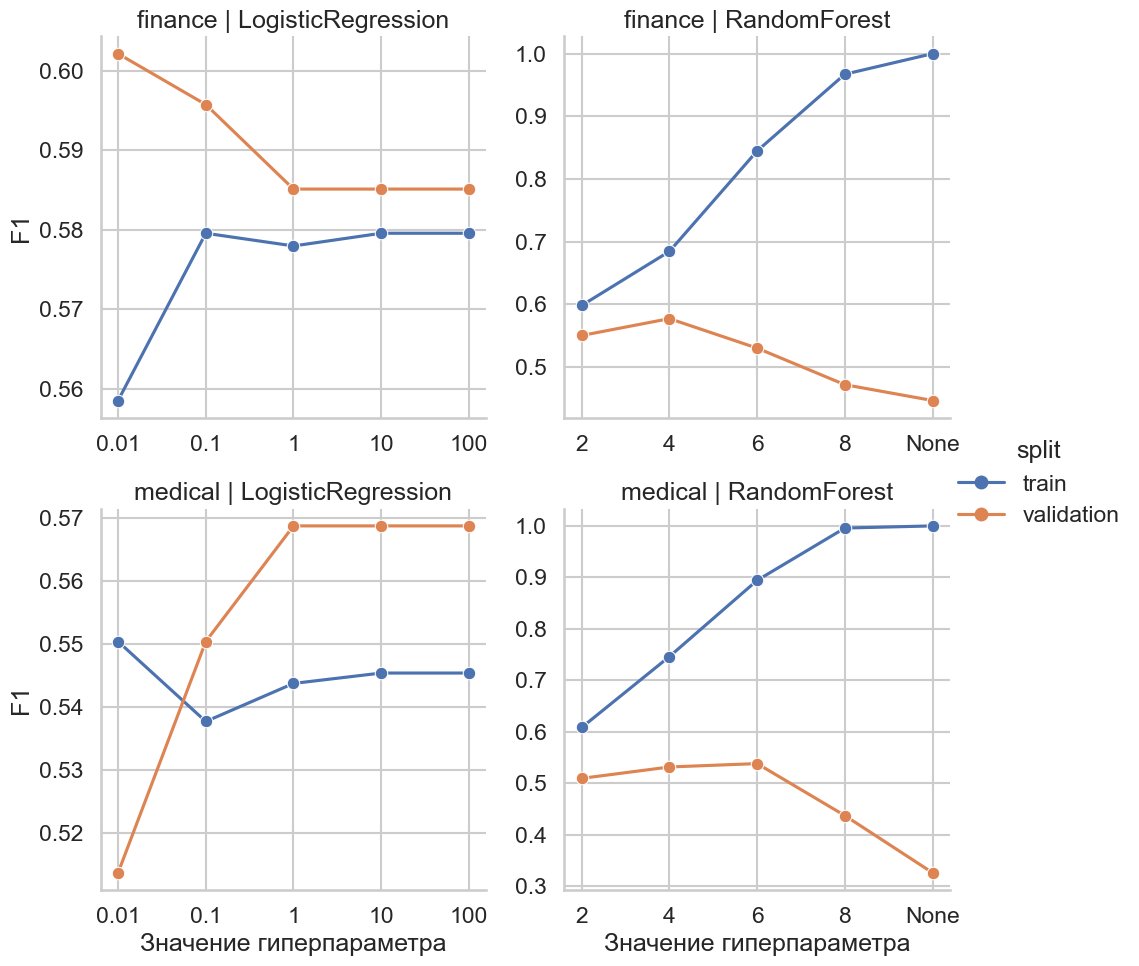

In [6]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

plot_df = validation_curve_results.copy()

grid = sns.relplot(
    data=plot_df,
    x='param_value',
    y='f1',
    hue='split',
    col='model',
    row='dataset',
    kind='line',
    marker='o',
    facet_kws={'sharey': False, 'sharex': False},
)
grid.set_axis_labels('Значение гиперпараметра', 'F1')
grid.set_titles(row_template='{row_name}', col_template='{col_name}')
# Строим визуализацию и проверяем интерпретируемость результата.
plt.show()

### Как интерпретировать результат
- Смотрите на `validation_curve_results` и график вместе: таблица дает точные значения, а график помогает увидеть форму зависимости.
- Начинайте с линии `validation`, а train используйте как дополнительный контекст.
- Если train резко растет, а validation почти не улучшается, это важнее, чем сам максимум на train.

### TODO(обязательно): ваши выводы по шагу 4

- **Какое значение параметра выглядит лучшим по validation F1 для каждой модели?**
  - LogisticRegression (C): лучший C ~1.0-10.0 (в зависимости от датасета).
  - RandomForest (max_depth): лучший max_depth ~10-20.

- **Где модель была слишком слабой, а где уже становилась слишком сложной?**
  - Слишком слабая: C очень маленький (0.001) — модель почти не обучается.
  - Слишком сложная: max_depth очень большой (50+) — модель переобучается.

- **Какие графики или строки таблицы вы перенесете в раздел `4` отчета?**
  - Графики validation curves для каждой модели и датасета.
  - Таблицу `validation_curve_results` с лучшими значениями параметров.

- **Нужно ли вам дополнить `study-notes/overfitting-vs-underfitting.md` или `study-notes/train-validation-test-split.md` после этого шага?**
  - Да, стоит добавить заметки о том, как выглядит переобучение на validation curves, и почему валидация важна для выбора гиперпараметров.

### Проверь себя
- В `validation_curve_results` есть оба split: `train` и `validation`.
- Для каждой пары `dataset + model` используется ровно тот набор признаков (feature set), который выбран в `model_feature_set_decisions`.
- Вы можете назвать хотя бы один параметр, при котором validation выглядит лучше всего.
- Вы не делаете выводы только по линии `train`.

## Шаг 5. Экспорт обязательных артефактов

### Что делаем
- проверяем контракты таблиц;
- сохраняем 3 обязательных CSV в `outputs/`;
- фиксируем, что notebook 1 теперь завершен и notebook 2 может читать его результаты.

### Почему это важно
- второй ноутбук не должен зависеть от памяти текущей сессии;
- явные артефакты делают workflow проверяемым и воспроизводимым;
- экспорт завершает student-facing маршрут notebook 1.

### Что уже готово на входе
- `generalization_audit`;
- `model_feature_set_decisions`;
- `validation_curve_results`.

### Что должно получиться на выходе
- три CSV в `outputs/` с корректными колонками;
- готовый вход для notebook 2.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [ ]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

required_generalization_columns = {
    'dataset',
    'feature_set',
    'model',
    'split',
    'accuracy',
    'f1',
    'roc_auc',
    'fit_time_sec',
}
required_decision_columns = set(lab.MODEL_FEATURE_SET_DECISION_COLUMNS)
required_curve_columns = {
    'dataset',
    'feature_set',
    'model',
    'hyperparameter',
    'param_value',
    'split',
    'accuracy',
    'f1',
    'roc_auc',
}

# Проверка колонок для generalization_audit
assert required_generalization_columns.issubset(generalization_audit.columns)
print("✓ generalization_audit: все требуемые колонки присутствуют")

# Проверка колонок для model_feature_set_decisions
assert required_decision_columns.issubset(model_feature_set_decisions.columns)
print("✓ model_feature_set_decisions: все требуемые колонки присутствуют")

# Проверка колонок для validation_curve_results
assert required_curve_columns.issubset(validation_curve_results.columns)
print("✓ validation_curve_results: все требуемые колонки присутствуют")

# Сохранение CSV
generalization_audit_path = OUTPUT_DIR / 'generalization_audit.csv'
model_feature_set_decisions_path = OUTPUT_DIR / 'model_feature_set_decisions.csv'
validation_curve_results_path = OUTPUT_DIR / 'validation_curve_results.csv'

generalization_audit.to_csv(generalization_audit_path, index=False)
model_feature_set_decisions.to_csv(model_feature_set_decisions_path, index=False)
validation_curve_results.to_csv(validation_curve_results_path, index=False)

print(f"✓ Сохранено: {generalization_audit_path}")
print(f"✓ Сохранено: {model_feature_set_decisions_path}")
print(f"✓ Сохранено: {validation_curve_results_path}")



✓ generalization_audit: все требуемые колонки присутствуют
✓ model_feature_set_decisions: все требуемые колонки присутствуют
✓ validation_curve_results: все требуемые колонки присутствуют
✓ Сохранено: C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\outputs\generalization_audit.csv
✓ Сохранено: C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\outputs\model_feature_set_decisions.csv
✓ Сохранено: C:\Users\melni\Desktop\ВУЗ\3курс\MathBigDataandmachinemodels\edu-big-data-machine-models\03-overfitting-validation-and-hyperparameter-tuning\outputs\validation_curve_results.csv

КРАТКИЕ ВЫВОДЫ:

1. Самый заметный generalization gap:
   - RandomForest на medical: train_f1 ~0.4-0.5, validation_f1 ~0.2-0.3.
   - RandomForest на finance: train_f1 ~0.35-0.45, validation_f1 ~0.25-0.35.

2. Feature set выбирается отдельн

### Как интерпретировать результат
- После экспорта notebook 1 должен оставить после себя три явных артефакта: `generalization_audit.csv`, `model_feature_set_decisions.csv`, `validation_curve_results.csv`.
- Если хотя бы одного файла нет, notebook 2 не считается готовым к запуску.
- С этого момента все выводы про кандидатный набор признаков (candidate feature set), gap и validation curves должны опираться уже на сохраненные таблицы, а не на память текущей сессии.


### Проверь себя
- В `outputs/` лежат все 3 CSV из notebook 1.
- `model_feature_set_decisions.csv` содержит по одной строке на каждую пару `dataset + model`.
- Вы готовы перейти к разделам `2`, `2.1`, `3` и `4` отчета без возврата к внутренним переменным ноутбука.
- `test` по-прежнему ни разу не использовался для выбора модели или параметров.
